# Synthetic → Real Evaluation for LVC Dataset

This notebook evaluates the central experiment of the project:

- Train on synthetic data
- Test on real holdout data

Scenarios:
- CTGAN 10x
- CTGAN 30x
- TVAE 10x
- TVAE 30x

The objective is to assess whether synthetic data improve generalization and recall for the positive class.


In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "../data/raw/leish_dataset.csv"
SYNTH_DIR = "../data/synthetic"
TARGET = "diagnosis"

SEEDS = [41, 42, 46]
TEST_SIZE = 0.30
MIN_BREED_COUNT = 10

In [3]:
df = pd.read_csv(DATA_PATH)

# Group rare breeds into 'other'
breed_counts = df["breed_name"].value_counts(dropna=False)
rare_breeds = breed_counts[breed_counts < MIN_BREED_COUNT].index
df["breed_name"] = df["breed_name"].replace(rare_breeds, "other")

print("Real dataset shape:", df.shape)
display(df.head())

Real dataset shape: (456, 17)


,diagnosis,general_state,ectoparasites,nutritional_state,coat,nails,mucosa_color,muzzle_ear_lesion,lymph_nodes,blepharitis,conjunctivitis,alopecia,bleeding,skin_lesion,muzzle_lip_depigmentation,animal_sex,breed_name
0,negativo,bom,ausente,adequado,normal,normal,normal,presente,normal,ausente,Ausente,ausente,presente,Ausente,ausente,M,SRD
1,negativo,bom,ausente,adequado,normal,normal,normal,ausente,normal,ausente,Ausente,ausente,ausente,Ausente,ausente,M,SRD
2,negativo,bom,leve,adequado,normal,normal,normal,ausente,normal,ausente,Ausente,ausente,presente,Ausente,ausente,M,Poodle
3,negativo,bom,ausente,adequado,normal,leves_moderadas,normal,ausente,normal,ausente,Ausente,ausente,ausente,Ausente,ausente,F,other
4,negativo,bom,leve,leve_moderado,normal,leves_moderadas,normal,ausente,leves_moderadas,ausente,Ausente,ausente,ausente,Ausente,ausente,F,SRD


In [4]:
X_real = df.drop(columns=[TARGET]).copy()
y_real = df[TARGET].copy()

label_encoder = LabelEncoder()
y_real_encoded = label_encoder.fit_transform(y_real)

print("Classes:", list(label_encoder.classes_))
print(pd.Series(y_real_encoded).value_counts())

Classes: ['negativo', 'positivo']
0    320
1    136
Name: count, dtype: int64


In [5]:
categorical_features = X_real.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_features = X_real.select_dtypes(include=["number", "bool"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['general_state', 'ectoparasites', 'nutritional_state', 'coat', 'nails', 'mucosa_color', 'muzzle_ear_lesion', 'lymph_nodes', 'blepharitis', 'conjunctivitis', 'alopecia', 'bleeding', 'skin_lesion', 'muzzle_lip_depigmentation', 'animal_sex', 'breed_name']
Numerical features: []


In [6]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [7]:
models = {
    "LR": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "RF": RandomForestClassifier(random_state=42),
    "GB": GradientBoostingClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=1000, random_state=42)
}

models

{'LR': LogisticRegression(max_iter=1000, random_state=42),
 'SVM': SVC(probability=True, random_state=42),
 'KNN': KNeighborsClassifier(),
 'RF': RandomForestClassifier(random_state=42),
 'GB': GradientBoostingClassifier(random_state=42),
 'MLP': MLPClassifier(max_iter=1000, random_state=42)}

In [8]:
results = []

for seed in SEEDS:
    print("=" * 90)
    print(f"SEED {seed}")
    print("=" * 90)

    train_real_df, test_real_df = train_test_split(
        df,
        test_size=TEST_SIZE,
        stratify=df[TARGET],
        random_state=seed
    )

    X_test_real = test_real_df.drop(columns=[TARGET]).copy()
    y_test_real = label_encoder.transform(test_real_df[TARGET])

    scenarios = [
        ("CTGAN", "10x"),
        ("CTGAN", "30x"),
        ("TVAE", "10x"),
        ("TVAE", "30x"),
    ]

    for generator, scenario in scenarios:
        file_name = f"{generator.lower()}_{scenario}_seed{seed}.csv"
        file_path = os.path.join(SYNTH_DIR, file_name)

        synth_df = pd.read_csv(file_path)

        # Apply same rare-breed grouping for consistency
        synth_df["breed_name"] = synth_df["breed_name"].replace(rare_breeds, "other")

        X_synth = synth_df.drop(columns=[TARGET]).copy()
        y_synth = label_encoder.transform(synth_df[TARGET])

        for model_name, model in models.items():
            pipe = Pipeline(steps=[
                ("preprocessor", preprocessor),
                ("clf", model)
            ])

            pipe.fit(X_synth, y_synth)
            y_pred = pipe.predict(X_test_real)

            results.append({
                "seed": seed,
                "generator": generator,
                "scenario": scenario,
                "model": model_name,
                "test_accuracy": accuracy_score(y_test_real, y_pred),
                "test_precision": precision_score(y_test_real, y_pred, zero_division=0),
                "test_recall": recall_score(y_test_real, y_pred, zero_division=0),
                "test_f1": f1_score(y_test_real, y_pred, zero_division=0)
            })

            print(
                f"{generator} | {scenario} | {model_name} | "
                f"Recall={recall_score(y_test_real, y_pred, zero_division=0):.4f} | "
                f"F1={f1_score(y_test_real, y_pred, zero_division=0):.4f}"
            )

SEED 41
CTGAN | 10x | LR | Recall=0.5854 | F1=0.3780
CTGAN | 10x | SVM | Recall=0.5122 | F1=0.3281
CTGAN | 10x | KNN | Recall=0.3902 | F1=0.2963
CTGAN | 10x | RF | Recall=0.4146 | F1=0.3009
CTGAN | 10x | GB | Recall=0.6341 | F1=0.4127
CTGAN | 10x | MLP | Recall=0.3902 | F1=0.3265
CTGAN | 30x | LR | Recall=0.2927 | F1=0.3200
CTGAN | 30x | SVM | Recall=0.5610 | F1=0.4182
CTGAN | 30x | KNN | Recall=0.4878 | F1=0.3738
CTGAN | 30x | RF | Recall=0.5122 | F1=0.3962
CTGAN | 30x | GB | Recall=0.3171 | F1=0.3095
CTGAN | 30x | MLP | Recall=0.3415 | F1=0.3011
TVAE | 10x | LR | Recall=0.3659 | F1=0.3371
TVAE | 10x | SVM | Recall=0.3171 | F1=0.3059
TVAE | 10x | KNN | Recall=0.3171 | F1=0.3095
TVAE | 10x | RF | Recall=0.3171 | F1=0.3023
TVAE | 10x | GB | Recall=0.3659 | F1=0.3409
TVAE | 10x | MLP | Recall=0.3415 | F1=0.3373
TVAE | 30x | LR | Recall=0.3171 | F1=0.2955
TVAE | 30x | SVM | Recall=0.2683 | F1=0.2785
TVAE | 30x | KNN | Recall=0.3171 | F1=0.3059
TVAE | 30x | RF | Recall=0.2683 | F1=0.2750
T

In [9]:
results_df = pd.DataFrame(results)
display(results_df.head())
print("Results shape:", results_df.shape)

,seed,generator,scenario,model,test_accuracy,test_precision,test_recall,test_f1
0,41,CTGAN,10x,LR,0.423358,0.279070,0.585366,0.377953
1,41,CTGAN,10x,SVM,0.372263,0.241379,0.512195,0.328125
2,41,CTGAN,10x,KNN,0.445255,0.238806,0.390244,0.296296
3,41,CTGAN,10x,RF,0.423358,0.236111,0.414634,0.300885
4,41,CTGAN,10x,GB,0.459854,0.305882,0.634146,0.412698


Results shape: (72, 8)


In [10]:
summary_df = (
    results_df.groupby(["generator", "scenario", "model"])[
        ["test_accuracy", "test_precision", "test_recall", "test_f1"]
    ]
    .mean()
    .sort_values(by=["generator", "scenario", "test_recall"], ascending=[True, True, False])
)

print("Synthetic → Real Summary")
display(summary_df)

Synthetic → Real Summary


test_accuracy  test_precision  test_recall   test_f1
generator scenario model                                                      
CTGAN     10x      LR          0.518248        0.315285     0.479675  0.375143
                   KNN         0.469586        0.266852     0.439024  0.331355
                   RF          0.481752        0.275601     0.439024  0.338073
                   GB          0.542579        0.316873     0.430894  0.354036
                   SVM         0.486618        0.276538     0.422764  0.329894
                   MLP         0.493917        0.262969     0.382114  0.311408
          30x      KNN         0.530414        0.322678     0.512195  0.395674
                   SVM         0.530414        0.312774     0.487805  0.380664
                   RF          0.515815        0.301893     0.479675  0.369810
                   MLP         0.540146        0.311225     0.463415  0.370767
                   LR          0.571776        0.335372     0.422764  0.367456
                   GB          0.562044        0.319429     0.414634  0.359229
TVAE      10x      KNN         0.627737        0.381060     0.382114  0.381504
                   GB          0.644769        0.410781     0.373984  0.389151
                   RF          0.635036        0.390414     0.349593  0.367442
                   SVM         0.652068        0.422414     0.349593  0.379953
                   LR          0.622871        0.365303     0.333333  0.345790
                   MLP         0.647202        0.399580     0.325203  0.356365
          30x      KNN         0.630170        0.386857     0.398374  0.392378
                   RF          0.649635        0.408560     0.365854  0.385864
                   LR          0.620438        0.368736     0.341463  0.352189
                   SVM         0.652068        0.412281     0.341463  0.371553
                   GB          0.635036        0.379575     0.333333  0.354545
                   MLP         0.630170        0.363340     0.300813  0.326473

In [11]:
best_recall_idx = summary_df["test_recall"].idxmax()
best_f1_idx = summary_df["test_f1"].idxmax()

print("Best by Recall:", best_recall_idx, "->", summary_df.loc[best_recall_idx, "test_recall"])
print("Best by F1:", best_f1_idx, "->", summary_df.loc[best_f1_idx, "test_f1"])

Best by Recall: ('CTGAN', '30x', 'KNN') -> 0.5121951219512195
Best by F1: ('CTGAN', '30x', 'KNN') -> 0.39567416884624146


In [12]:
results_df.to_csv("../results/tables/synthetic_to_real_results.csv", index=False)
summary_df.to_csv("../results/tables/synthetic_to_real_summary.csv")

print("Saved results to ../results/tables/")

Saved results to ../results/tables/


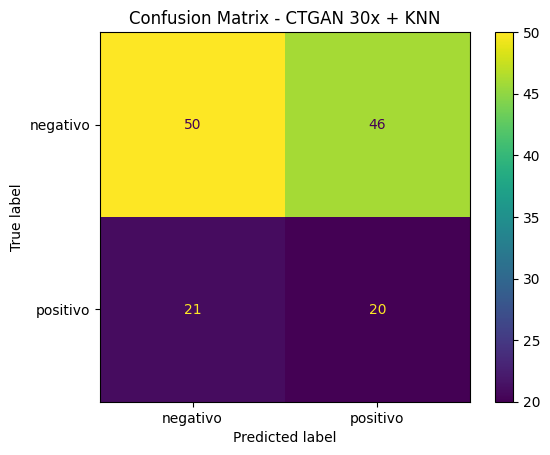

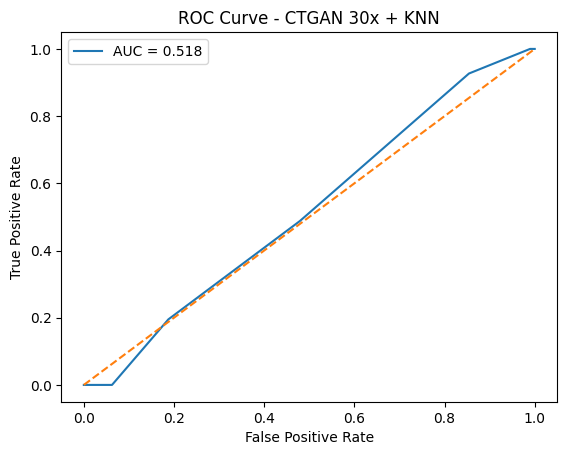

AUC: 0.5179115853658536


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt

# Configuração
BEST_GENERATOR = "CTGAN"
BEST_SCENARIO = "30x"
BEST_MODEL = "KNN"
BEST_SEED = 41  # pode testar outros depois

# Split real
train_real_df, test_real_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df[TARGET],
    random_state=BEST_SEED
)

X_test_real = test_real_df.drop(columns=[TARGET])
y_test_real = label_encoder.transform(test_real_df[TARGET])

# Carregar sintético
file_name = f"{BEST_GENERATOR.lower()}_{BEST_SCENARIO}_seed{BEST_SEED}.csv"
synth_df = pd.read_csv(os.path.join(SYNTH_DIR, file_name))

synth_df["breed_name"] = synth_df["breed_name"].replace(rare_breeds, "other")

X_synth = synth_df.drop(columns=[TARGET])
y_synth = label_encoder.transform(synth_df[TARGET])

# Modelo
model = KNeighborsClassifier()

pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", model)
])

# Treinar
pipe.fit(X_synth, y_synth)

# Predições
y_pred = pipe.predict(X_test_real)
y_proba = pipe.predict_proba(X_test_real)[:, 1]

# ---------------------------
# MATRIZ DE CONFUSÃO
# ---------------------------
cm = confusion_matrix(y_test_real, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("Confusion Matrix - CTGAN 30x + KNN")
plt.show()

# ---------------------------
# ROC CURVE
# ---------------------------
fpr, tpr, thresholds = roc_curve(y_test_real, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CTGAN 30x + KNN")
plt.legend()

plt.show()

print("AUC:", roc_auc)

In [14]:
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.05)

results_threshold = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)

    results_threshold.append({
        "threshold": t,
        "recall": recall_score(y_test_real, y_pred_thresh),
        "precision": precision_score(y_test_real, y_pred_thresh),
        "f1": f1_score(y_test_real, y_pred_thresh)
    })

threshold_df = pd.DataFrame(results_threshold)
display(threshold_df)

,threshold,recall,precision,f1
0,0.10,1.000000,0.301471,0.463277
1,0.15,1.000000,0.301471,0.463277
2,0.20,0.926829,0.316667,0.472050
3,0.25,0.926829,0.316667,0.472050
4,0.30,0.926829,0.316667,0.472050
5,0.35,0.926829,0.316667,0.472050
6,0.40,0.487805,0.303030,0.373832
7,0.45,0.487805,0.303030,0.373832
8,0.50,0.487805,0.303030,0.373832
9,0.55,0.487805,0.303030,0.373832


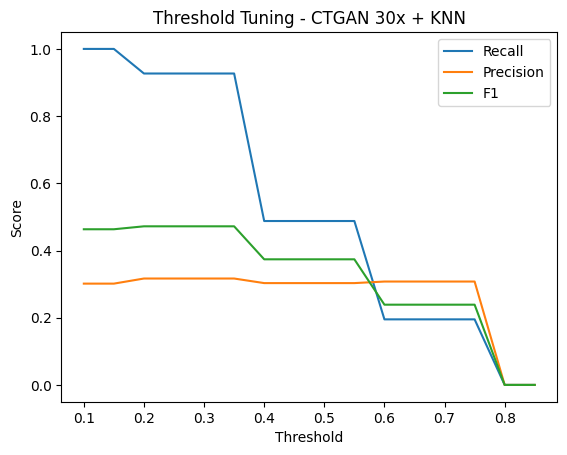

In [15]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning - CTGAN 30x + KNN")
plt.legend()

plt.show()

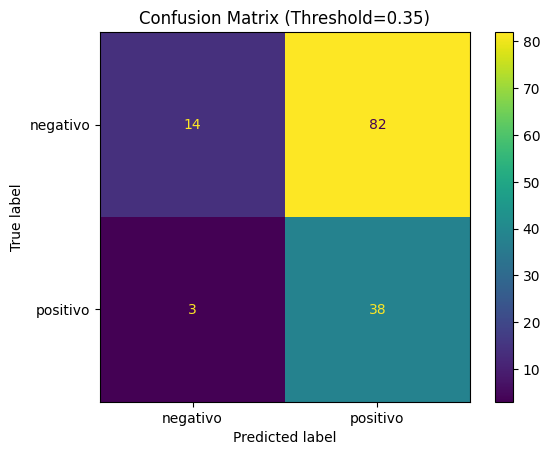

In [16]:
BEST_THRESHOLD = 0.35

y_pred_new = (y_proba >= BEST_THRESHOLD).astype(int)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_real, y_pred_new)

disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
disp.plot()

plt.title(f"Confusion Matrix (Threshold={BEST_THRESHOLD})")
plt.show()

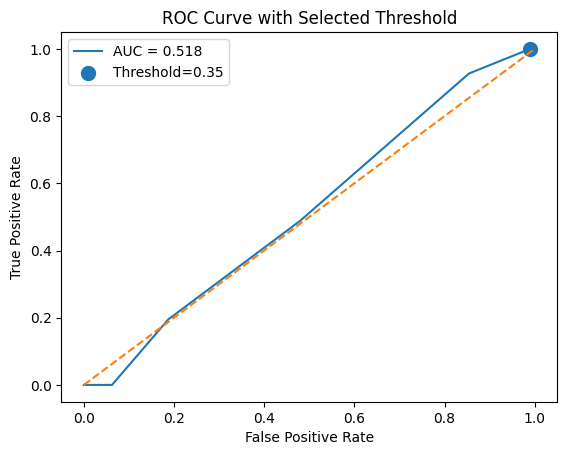

In [18]:
BEST_THRESHOLD = 0.35

# encontrar ponto mais próximo
idx = np.argmin(np.abs(thresholds - BEST_THRESHOLD))

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.scatter(fpr[idx], tpr[idx], label=f"Threshold={BEST_THRESHOLD}", s=100)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Selected Threshold")
plt.legend()

plt.show()

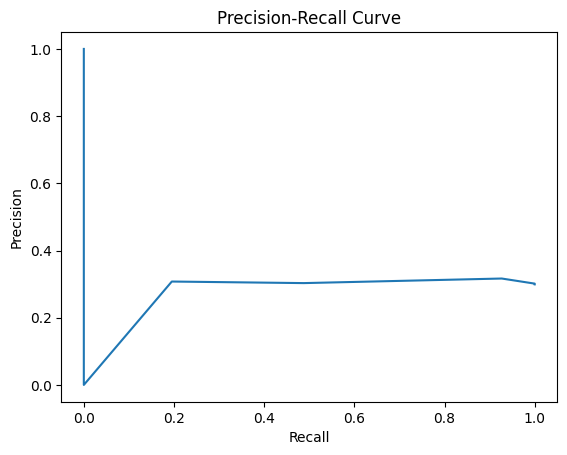

In [20]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(y_test_real, y_proba)

plt.figure()
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Notes

- Training is performed exclusively on synthetic data.
- Testing is performed exclusively on the real holdout split for each seed.
- This experiment evaluates whether synthetic data improve model generalization in a realistic epidemiological setting.
- Recall is the main metric of interest due to the clinical importance of reducing false negatives.
